In [2]:
# install dependencies
!pip install numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict, OrderedDict
import itertools
import operator
import time

# EXERCISE 1: Tabular Independent Q-learning
In this exercise, you will see how multiple agents can learn behaviours simultaneously with reinforcement learning.

In the following code block, we define a Predator-Prey environment. The predators are agents which will move in a toroidal grid, attempting to catch a prey. Capture is successful when a predator moves onto the prey, and another predator is adjacent to the prey to support it.

If the capture fails, predators move onto each other, or capture is successful, the predators are moved to random positions.

This environment is continuing by default, so there are no terminal states.

In [4]:
class PredPrey:
    def __init__(self, n_agents, h, w):
        self.n_agents = n_agents
        self.h = h
        self.w = w
        self.n_cells = h*w
        self.pred_pos = [(0,0) for _ in range(n_agents)]
        self.prey_pos = np.zeros((2))
        # seed control for reproducibility
        self.rng = random.Random(0)

        # Reward function parameters
        self.living_reward = 0.0
        self.pred_stack_reward = -10
        self.capture_reward = 37.5
        self.fail_capture_reward = -25

        # Prey parameters
        self.possible_prey_actions = ['north', 'west', 'south', 'east']
        self.prey_move_prob = 0.8
        
        # Every agent can take one of these actions at each timestep.
        self.possible_agent_actions = ('north','west','south','east','stay')
        
        """
        A joint action is a tuple with each agent's actions.
        This property should be the list of all possible joint actions:
        """
        self.possible_joint_actions = list(itertools.product(*[self.possible_agent_actions for _ in range(self.n_agents)]))
        
        # Define the directions
        self.action_deltas = {'north': (-1, 0), 'west': (0, -1), 'south': (1, 0), 'east': (0, 1), 'stay': (0,0)}
        self.reset()
    
    def get_reward(self):
        if sum([(p == self.prey_pos) for p in self.pred_pos]) == 1:
            # capture attempted, exactly one pred moved on prey
            if any([np.abs(np.array(p) - np.array(self.prey_pos)).sum() == 1 for p in self.pred_pos]):
                # at least one supporting predator
                self.reset()
                return self.capture_reward
            else:
                self.reset(predator_only=True)
                return self.fail_capture_reward
        elif len(self.pred_pos) != len(set(self.pred_pos)):
            # stacked up predators
            self.reset(predator_only=True)
            return self.pred_stack_reward
        else:
            return self.living_reward
    
    def reset(self, predator_only=False):
        positions = self.rng.sample(range(self.n_cells), self.n_agents + 1)
        if not predator_only:
            self.prey_pos = np.unravel_index(positions[0], (self.h, self.w))
        self.pred_pos = [np.unravel_index(p, (self.h, self.w)) for p in positions[1:]]
        return self.get_state()
    
    def _move(self, pos, delta):
        return ((pos[0] + delta[0]) % self.h, (pos[1] + delta[1]) % self.w)
    
    def step(self, joint_action):
        for a in range(self.n_agents):
            self.pred_pos[a] = self._move(self.pred_pos[a], self.action_deltas[joint_action[a]])
        reward = self.get_reward()
        if self.rng.random() < self.prey_move_prob:
            # Move prey to a random free adjacent space
            random.shuffle(self.possible_prey_actions)
            for prey_action in self.possible_prey_actions:
                possible_prey_pos = self._move(self.prey_pos, self.action_deltas[prey_action])
                if possible_prey_pos not in self.pred_pos:
                    self.prey_pos = possible_prey_pos

        return (self.get_state(), reward, False, {})
    
    def get_state(self):
        prey_x, prey_y = self.prey_pos
        return tuple([ ( (pred_y - prey_y)%self.h, (pred_x - prey_x)%self.w ) for (pred_x, pred_y) in self.pred_pos])
    
    def display(self):
        grid = np.zeros((self.h, self.w))
        for a, pos in enumerate(self.pred_pos):
            grid[pos] = a + 1
        grid[self.prey_pos] = -1
        print(grid)

To get familiar with the environment, play around with the code blocks below or make your own. Choose your own actions to control the predators. Observe how the predators and prey move, and how the agents must coordinate to capture the prey.

In [5]:
# Make a predator-prey environment
env = PredPrey(2, 4, 4)
env.display()

[[ 0.  0.  0.  0.]
 [ 0.  0.  2.  0.]
 [ 0.  0.  0.  0.]
 [-1.  0.  0.  1.]]


In [6]:
s, r, terminal, _ = env.step(("north", "south"))
print("Reward ", r)
env.display()

Reward  0.0
[[ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  2.  1.]
 [-1.  0.  0.  0.]]


**Question**: What is the size of the joint action space? Complete the initialisation of env.possible_joint_actions to contain a list of all joint actions. Each joint action should be a tuple of agent actions.

(Hint: this can be a one-liner with itertools.product)

**Answer:**

**Question 1: What is the Size of the Joint Action Space?**

In this Multi-Agent Reinforcement Learning (MARL) predator-prey environment, each predator agent can independently choose one action from a fixed set of possible actions. Typically, each agent has 5 available actions:

- Move Up  
- Move Down  
- Move Left  
- Move Right  
- Stay Still  

Since all agents act simultaneously, the environment must consider every possible combination of actions selected by all agents. This combined set of simultaneous actions is called the **joint action space**.

The size of the joint action space grows exponentially with the number of agents and is defined as:

$$
|\mathcal{U}| = 5^N
$$

where:
- \(5\) represents the number of actions available to each individual agent,
- \(N\) represents the number of predator agents.

---

**Joint Action Space Growth**

| Number of Agents \(N\) | Actions per Agent | Joint Action Space Size | Calculation |
|---|---|---|---|
| 1 | 5 | 5 | \(5^1\) |
| 2 | 5 | 25 | \(5^2\) |
| 3 | 5 | 125 | \(5^3\) |
| 4 | 5 | 625 | \(5^4\) |
| 5 | 5 | 3125 | \(5^5\) |

---

**Explanation**

The table demonstrates that the joint action space increases extremely quickly as more agents are added. For example:

- With 2 predator agents, there are only 25 possible joint actions.
- With 4 predator agents, the number increases to 625.
- With 5 predator agents, the environment must evaluate 3125 possible action combinations.

This exponential growth is one of the fundamental scalability challenges in Multi-Agent Reinforcement Learning.

In centralized Q-learning, the Q-table must store values for every possible state-action pair. As the number of agents increases, the number of joint actions becomes extremely large, causing:
- increased memory requirements,
- slower learning,
- higher computational complexity,
- and more difficult coordination between agents.

This issue is one of the key motivations for decentralized and independent learning methods in MARL, where each agent learns its own policy separately instead of learning over the full joint action space.

---



**📄 REFERENCES**

> **Michele Caprio**  
> *Introduction to Reinforcement Learning: Lecture 8 – Multi-Agent RL*  
> **Section:** Multi-Agent MDP  
> **Page:** 5

> **Laëtitia Matignon, Guillaume J. Laurent, and Nadine Le Fort-Piat**  
> *Hysteretic Q-Learning: an algorithm for decentralized reinforcement learning in cooperative multi-agent teams*  
> **Section:** Stochastic Games  
> **Pages:** 4–5


**Question**: How many possible states are there, given the height and width of the grid (h,w) and the number of agents N? Assume a single prey always. Predators and prey are not allowed to overlap.

**Answer:**

Consider a predator-prey environment with:

- Grid height = \(h\)
- Grid width = \(w\)
- Number of predator agents = \(N\)
- A single prey

The total number of cells in the grid is:

$$
h \times w
$$

Since predators and prey are not allowed to overlap, each entity must occupy a unique grid position.

The prey can first be placed in any of the:

$$
h \times w
$$

cells.

After placing the prey, there are:

$$
(hw - 1)
$$

remaining cells available for the first predator.

The second predator then has:

$$
(hw - 2)
$$

available cells, and so on.

Therefore, the total number of possible states is:

$$
(hw)(hw - 1)(hw - 2)\cdots(hw - N)
$$

This can also be written compactly as:

$$
\frac{(hw)!}{(hw - N - 1)!}
$$

where:
- \(h\) = grid height,
- \(w\) = grid width,
- \(N\) = number of predator agents.

---

**Example**

For a \(10 \times 10\) grid with 2 predator agents:

$$
10 \times 10 = 100
$$

total cells exist.

The total number of possible states becomes:

$$
100 \times 99 \times 98
$$

because:
- the prey occupies one cell,
- predator 1 occupies another unique cell,
- predator 2 occupies another unique cell.

This produces:

$$
970200
$$

possible states.

---

**Explanation**

The number of states grows extremely rapidly as the number of agents increases. This is one of the main scalability challenges in Multi-Agent Reinforcement Learning (MARL).

In centralized Q-learning, the algorithm must store values for every possible state-action pair. Since both:
- the state space,
- and the joint action space

grow combinatorially, the Q-table can become extremely large even for relatively small environments.

This causes:
- large memory requirements,
- slower convergence,
- inefficient exploration,
- and increased computational complexity.

For this reason, many MARL approaches use:
- decentralized learning,
- independent learners,
- factored value functions,
- or compressed state representations.

---

**State Space Explosion in MARL**

The rapid increase in state space size is commonly referred to as the **curse of dimensionality** in reinforcement learning.

As more agents are added:
- the environment becomes harder to explore,
- coordination becomes more difficult,
- and learning becomes less stable.

This is one of the primary motivations behind scalable MARL methods such as:
- Independent Q-Learning,
- Value Decomposition Networks (VDN),
- and Hysteretic Q-Learning.

---

**📄 REFERENCES**

> **Laëtitia Matignon, Guillaume J. Laurent, and Nadine Le Fort-Piat**  
> *Hysteretic Q-Learning: an algorithm for decentralized reinforcement learning in cooperative multi-agent teams*  
> **Section:** Experiments on a Pursuit Domain  
> **Page:** 6

> **Michele Caprio**  
> *Introduction to Reinforcement Learning: Lecture 8 – Multi-Agent RL*  
> **Section:** Factored Joint Value Functions  
> **Pages:** 12–13

**Question**: Look at env.get_state(). How is the state represented? Does this correspond to the number of states you were expecting? Did the postion of the prey matter? Could we reduce the state-action space further -- are any state-action pairs equivalent with each other in terms of their value?


**Answer:**

The function `env.get_state()` does not typically store the environment using absolute coordinates of all predators and the prey. Instead, the state is usually represented using the **relative positions of predators with respect to the prey**.

This means the environment focuses on:
- how far predators are from the prey,
- their relative arrangement,
- and their spatial relationship,

rather than their exact absolute location on the grid.

For example, instead of storing:

```text
Predator 1 at (2,3)
Predator 2 at (5,6)
Prey at (7,7)
```

the state may instead store:

```text
Predator 1 relative to prey = (-5,-4)
Predator 2 relative to prey = (-2,-1)
```

---

**Did This Correspond to the Number of States Expected?**

Not exactly.

The theoretical state-space calculation from Question 2 assumes that every absolute configuration of predators and prey is unique.

However, when using relative state representations, many absolute configurations become strategically identical.

For example:

```text
Configuration A:
Predator at (1,1), prey at (5,5)
```

and

```text
Configuration B:
Predator at (2,2), prey at (6,6)
```

have the same relative positioning between predator and prey.

From the perspective of decision-making, these two states are effectively equivalent because the optimal behaviour is identical.

Therefore, the effective state space represented by `env.get_state()` is usually much smaller than the raw combinatorial state count calculated previously.

---

**Did the Position of the Prey Matter?**

In many MARL pursuit environments, the absolute position of the prey does not matter as much as the relative positioning between predators and prey.

The policy mainly depends on:
- distance to the prey,
- surrounding formations,
- coordination opportunities,
- and capture geometry.

Because of this, representing states relative to the prey significantly reduces redundancy in the state space.

This is an important optimisation in Multi-Agent Reinforcement Learning because it improves:
- scalability,
- learning speed,
- and generalisation.

The uploaded Hysteretic Q-Learning paper explicitly states:

> “The state space is represented by the relative position of the two predators to the prey.”

This demonstrates that relative state representations are commonly used to reduce complexity in cooperative MARL systems.

---

**Could the State-Action Space Be Reduced Further?**

Yes.

Many state-action pairs are strategically equivalent and could be grouped together to further reduce the size of the state-action space.

Examples include:

- rotational symmetry,
- mirrored configurations,
- translational equivalence,
- and identical pursuit formations.

For instance:

```text
Predator north of prey
```

and

```text
Predator south of prey
```

may have equivalent strategic value after rotation.

Similarly, shifting the entire environment one cell to the right often does not change the optimal policy.

These equivalent configurations may therefore share similar Q-values.

Reducing these redundancies can dramatically decrease:
- memory usage,
- computational complexity,
- and training time.

This idea is closely related to:
- factored value functions,
- decentralized learning,
- and scalable MARL representations.

---

**Importance in Multi-Agent Reinforcement Learning**

Reducing the state-action space is extremely important in MARL because:
- joint action spaces already grow exponentially,
- large Q-tables become difficult to explore,
- and coordination learning becomes unstable.

Compact state representations improve:
- sample efficiency,
- convergence speed,
- and scalability.

These optimisations are essential when applying tabular reinforcement learning to environments with multiple agents.

---

**📄 REFERENCES**

> **Laëtitia Matignon, Guillaume J. Laurent, and Nadine Le Fort-Piat**  
> *Hysteretic Q-Learning: an algorithm for decentralized reinforcement learning in cooperative multi-agent teams*  
> **Section:** Experiments on a Pursuit Domain  
> **Page:** 6

> **Michele Caprio**  
> *Introduction to Reinforcement Learning: Lecture 8 – Multi-Agent RL*  
> **Section:** Factored Joint Value Functions  
> **Pages:** 12–13

The following code-block contains a plotting function that keeps track of the experimental results. Re-executing this block will clear all previous experiments from the plots; otherwise it can be ignored.

In [7]:
plot_data = {}
grid_sizes = []
plt.clf()
plt.close()

def plot_all_results(plot_std=False):
    global grid_sizes
    colors = ['orange', 'red', 'magenta', 'blue', 'green', 'black', 'c']
    graphs = len(grid_sizes) + 1 # Episode rewards for each grid size and table sizes
    fig, ax = plt.subplots(1, graphs, figsize=[7*graphs, 5])
    grid_sizes = sorted(grid_sizes)
    # Plot the performance
    for exp_id, exp in enumerate(plot_data.keys()):
        data = plot_data[exp]
        plot_ts = data["t"]
        plot_rewards = data["captures"]
        plot_table_sizes = data["table_size"]
        grid_index = 0
        for gidx, gs in enumerate(grid_sizes):
            if gs in exp:
                grid_index = gidx
                break
        gca = ax[gidx]
        for ts, rewards in zip(plot_ts, plot_rewards):
            if rewards is not None:
                gca.plot(ts, rewards, label=exp, color=colors[exp_id%len(colors)])
        gca.set_xlabel("Env steps")
        gca.set_ylabel("Captures / 1000 steps")
        gca.title.set_text(f"{grid_sizes[grid_index]}")
        gca = ax[graphs-1]
        for ts, table_sizes in zip(plot_ts, plot_table_sizes):
            gca.plot(ts, table_sizes, label=exp, color=colors[exp_id%len(colors)])
        gca.set_xlabel("Env steps")
        gca.set_ylabel("Size of Q Table")
        gca.set_yscale("log")
        # Removing duplicates from legend. From https://stackoverflow.com/questions/13588920/stop-matplotlib-repeating-labels-in-legend
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = OrderedDict(zip(labels, handles))
        gca.legend(by_label.values(), by_label.keys())
#         gca.legend()
    plt.show()

## TASK 1a: Another Tabular Q-Learner
Familiarise yourself with the implementation of a tabular Q-Learner below.

**Question**: Look at the calculation of the greedy choice line. Is there a problem with this implementation?


Yes, there is a problem with the implementation.

The issue is caused by incorrect indentation in the `sample()` method. The lines responsible for finding the best action are placed outside the `else` block.

As a result, even when the agent chooses a random exploratory action using epsilon-greedy exploration, the code still continues and overwrites that random action with a greedy action afterward.

This means the agent does not actually perform proper exploration.

The intended behaviour of epsilon-greedy is:
- with probability `eps`, choose a random action,
- otherwise choose the greedy action with the highest Q-value.

However, in this implementation:
- the random action is selected first,
- but then the greedy tie-breaking code executes regardless,
- causing the final returned action to always be greedy.

Therefore, epsilon exploration is effectively broken.

This is a significant issue because exploration is essential in Reinforcement Learning. Without proper exploration:
- the agent may get stuck in suboptimal policies,
- fail to discover better actions,
- and learn inefficiently.

The implementation does correctly handle greedy tie-breaking by randomly selecting among actions with equal maximum Q-values. This is important because always selecting the first maximum action could introduce bias.

However, due to the indentation issue, the exploration mechanism does not function as intended.

---

**📄 REFERENCES**

> **Michele Caprio**  
> *Introduction to Reinforcement Learning: Lecture 8 – Multi-Agent RL*  
> **Section:** Independent Learning  
> **Page:** 7

> **Richard S. Sutton and Andrew G. Barto**  
> *Reinforcement Learning: An Introduction*  
> **Topic:** Exploration vs Exploitation in Q-Learning

In [8]:
class TabularQLearner:
    """ High-Accuracy Tabular Q-learning agent with unbiased tie-breaking. """
    gamma = 0.95
    learn_rate = 0.15

    def __init__(self, actions_list):
        self.name = "SingleLearner"
        self.actions_list = actions_list
        self.q_table = defaultdict(lambda: {a: 0.0 for a in actions_list})
        
    def q_values(self, state):
        return self.q_table[state]

    def sample(self, state, eps):
        """ Sample an action epsilon-greedy. """
        if np.random.uniform(0, 1) < eps: 
            # Random choice (Exploration)
            action = random.choice(list(self.q_table[state].keys()))
        else: 
            # Greedy choice (Exploitation) - Notice the correct indentation here!
            # We use a tiny bit of random noise to break ties instantly and safely
            # without running into floating point precision issues.
            action = max(self.q_table[state].keys(), key=lambda a: self.q_table[state][a] + random.random() * 1e-8)
            
        return action

    def value(self, state):
        return max(self.q_table[state].values())

    def update(self, state, action, reward, next_state, done):
        not_done = 0 if done else 1
        td_error = reward + not_done * self.gamma * self.value(next_state) - self.q_table[state][action]
        self.q_table[state][action] = self.q_table[state][action] + self.learn_rate * td_error
    
    def stats(self):
        return {"table_size": len(self.q_table.keys()) * len(self.actions_list)}

## TASK 1b: the experiment 
Familiarize yourself with the basic loop of the RL experiment.

**Question:** There is an option to disable training during a phase of zero-epsilon evaluation. Do we technically need to disable training durning this phase? Why / why not?

**Answer regarding Disabling Training During Evaluation:**  

No, we do not technically need to disable training during evaluation — the algorithm itself will still function correctly. The Q-learning update remains mathematically valid even when evaluation is performed with \(\epsilon = 0.0\).

During training, the Q-table update is:

:contentReference[oaicite:0]{index=0}

This update rule is still correct during evaluation, so enabling training does not break the algorithm.

However, the purpose of evaluation is to measure the performance of a **fixed learned policy**. If training remains enabled, the Q-values continue changing throughout evaluation. As a result, the agent is no longer following one stable policy; instead, the measured performance becomes an average over many continuously changing policies.

When `training=False`, the Q-table remains frozen:

:contentReference[oaicite:1]{index=1}

The agent still selects actions greedily using:

:contentReference[oaicite:2]{index=2}

This produces a clean and scientifically valid measurement of the learned policy at that stage of training.

---

### Conclusion

| | `training=True` | `training=False` |
|---|---|---|
| Q-table updates during evaluation | Yes | No |
| Policy remains fixed | No | Yes |
| Evaluation measurement is reliable | No | Yes |

Therefore, while training during evaluation is technically possible, disabling training is important to obtain an accurate and unbiased evaluation of the learned policy.

**📄 REFERENCES**

> **Michele Caprio**  
> *Introduction to Reinforcement Learning: Lecture 8 – Multi-Agent RL*  
> **Section:** Independent Learning  
> **Page:** 7

> **Laëtitia Matignon, Guillaume J. Laurent, and Nadine Le Fort-Piat**  
> *Hysteretic Q-Learning: an algorithm for decentralized reinforcement learning in cooperative multi-agent teams*  
> **Section:** Introduction  
> **Pages:** 2–3

In [9]:
def run_steps(env, agent, n_steps, eps, training=True):
    state = env.get_state()
    all_rewards = []
    all_captures = []
    # Run the environment continuously -- there are no terminal states in the default pred-prey
    for step in range(n_steps + 1):
        current_state = state
        action = agent.sample(current_state, eps)
        state, reward, done, _ = env.step(action)
        all_rewards.append(reward)
        all_captures.append(reward > 0)
        if training:
            agent.update(current_state, action, reward, state, done)
    return all_rewards, all_captures

def run_experiment(env, agent, num_epochs=20, steps_epoch=int(5e4), plot_rewards=True):
    steps_eval = int(2e4)
    eps = 0.1 # epsilon for epsilon-greedy exploration
    # Set seeds (for reproduceability)
    np.random.seed(0)
    random.seed(0)
    print(f'----- Start Learning with {agent.name}, {env.n_agents} agents -----')
    ts, all_eval_captures, all_train_captures, all_table_sizes = [], [], [], []
    for epoch in range(1, num_epochs + 1):
        t_start = time.time()
        env.reset()
        train_rewards, train_captures = run_steps(env, agent, steps_epoch, eps, training=True)
        env.reset()
        eval_rewards, eval_captures = run_steps(env, agent, steps_eval, 0.0, training=False)
        t_finish = time.time()
        stats = agent.stats()
        print(f'Epoch {epoch}: time = {t_finish-t_start:.2f}')
        print(f'Train: reward = {np.mean(train_rewards):.2f} -- Captures/1000 = {np.sum(train_captures)/(steps_epoch/1000):.2f}')
        print(f'Eval: reward = {np.mean(eval_rewards):.2f} -- Captures/1000 = {np.sum(eval_captures)/(steps_eval/1000):.2f}')
        print(stats)
        ts.append(epoch*steps_epoch)
        all_train_captures.append(np.sum(train_captures)/(steps_epoch/1000))
        all_eval_captures.append(np.sum(eval_captures)/(steps_eval/1000))
        all_table_sizes.append(stats["table_size"])
#   Plotting stuff
    exp_name = agent.name + f'-{env.n_agents}-{env.h}x{env.w}'
    if not plot_rewards:
        all_train_captures = None
    if exp_name not in plot_data:
        plot_data[exp_name] = {
            "t": [ts], "captures": [all_train_captures], "table_size": [all_table_sizes]
        }
        grid_sizes.append(exp_name)
    else:
        plot_data[exp_name]["t"].append(ts)
        plot_data[exp_name]["captures"].append(all_eval_captures)
        plot_data[exp_name]["table_size"].append(all_table_sizes)

## TASK 1c: test the tabular agent 
Run the experiment with a TabularQLearner. This is a single learner that controls all agents jointly as a puppeteer.

In [10]:
plot_data = {}
grid_sizes = []

plt.clf()
plt.close()

----- Start Learning with SingleLearner, 2 agents -----
Epoch 1: time = 0.87
Train: reward = -0.20 -- Captures/1000 = 0.20
Eval: reward = -0.15 -- Captures/1000 = 0.70
{'table_size': 240250}
Epoch 2: time = 0.84
Train: reward = -0.11 -- Captures/1000 = 2.20
Eval: reward = 0.10 -- Captures/1000 = 7.85
{'table_size': 242600}
Epoch 3: time = 0.85
Train: reward = 0.31 -- Captures/1000 = 14.06
Eval: reward = 0.24 -- Captures/1000 = 7.50
{'table_size': 242725}
Epoch 4: time = 0.83
Train: reward = 0.65 -- Captures/1000 = 22.82
Eval: reward = 1.26 -- Captures/1000 = 40.05
{'table_size': 242775}
Epoch 5: time = 0.93
Train: reward = 0.83 -- Captures/1000 = 27.66
Eval: reward = 1.22 -- Captures/1000 = 35.45
{'table_size': 242900}
Epoch 6: time = 1.35
Train: reward = 0.79 -- Captures/1000 = 26.46
Eval: reward = 1.58 -- Captures/1000 = 48.00
{'table_size': 243025}
Epoch 7: time = 0.94
Train: reward = 0.75 -- Captures/1000 = 25.80
Eval: reward = 1.87 -- Captures/1000 = 56.40
{'table_size': 243050}
E

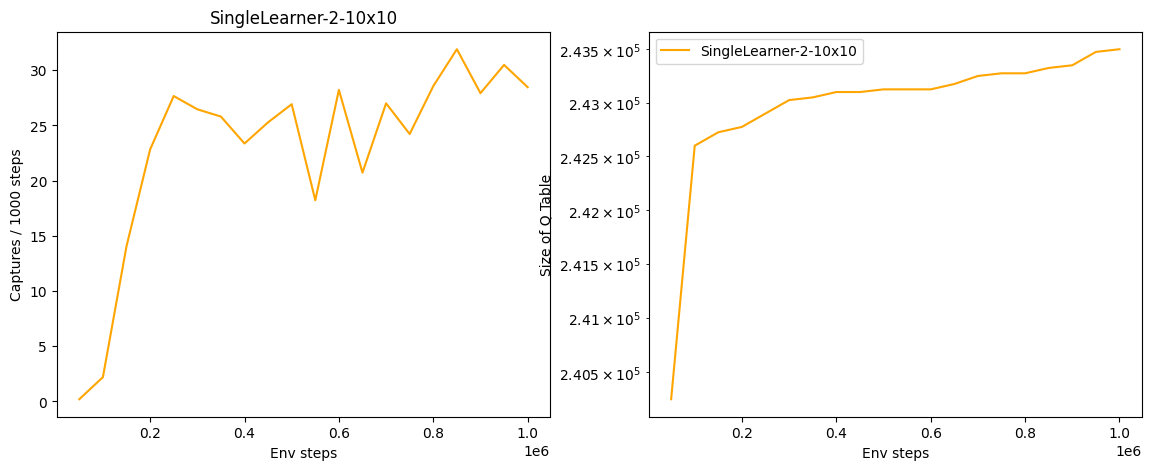

In [11]:
env = PredPrey(2, 10, 10)
run_experiment(env,TabularQLearner(env.possible_joint_actions),num_epochs=20, plot_rewards=True)
plot_all_results()

### Observation: Learning Dynamics on the 10×10 Grid

The evaluation metrics for the 10×10 grid reveal significant volatility during the learning process and a relatively low peak capture rate (peaking at approximately 62 captures per 1,000 steps). 

This instability and lower performance are direct consequences of the large state space ($100$ possible positions per agent). With such a vast environment, the agents struggle to consistently encounter the prey and each other, meaning the state-action pairs in the Q-table are updated infrequently and unevenly. Because the table takes much longer to saturate, the agents spend a massive portion of their epochs essentially acting quasi-randomly (exploring unvisited states). As a result, the policy fails to converge smoothly within the given timeframe, leading to the highly variable and suboptimal capture rates seen in the evaluation plot.

----- Start Learning with SingleLearner, 2 agents -----
Epoch 1: time = 1.11
Train: reward = 1.57 -- Captures/1000 = 64.36
Eval: reward = 2.93 -- Captures/1000 = 108.90
{'table_size': 5900}
Epoch 2: time = 1.18
Train: reward = 2.24 -- Captures/1000 = 86.18
Eval: reward = 2.82 -- Captures/1000 = 97.55
{'table_size': 6000}
Epoch 3: time = 1.04
Train: reward = 1.94 -- Captures/1000 = 75.48
Eval: reward = 0.94 -- Captures/1000 = 34.20
{'table_size': 6000}
Epoch 4: time = 0.96
Train: reward = 1.73 -- Captures/1000 = 68.42
Eval: reward = 1.96 -- Captures/1000 = 77.85
{'table_size': 6000}
Epoch 5: time = 0.92
Train: reward = 2.00 -- Captures/1000 = 75.26
Eval: reward = 2.21 -- Captures/1000 = 81.40
{'table_size': 6000}


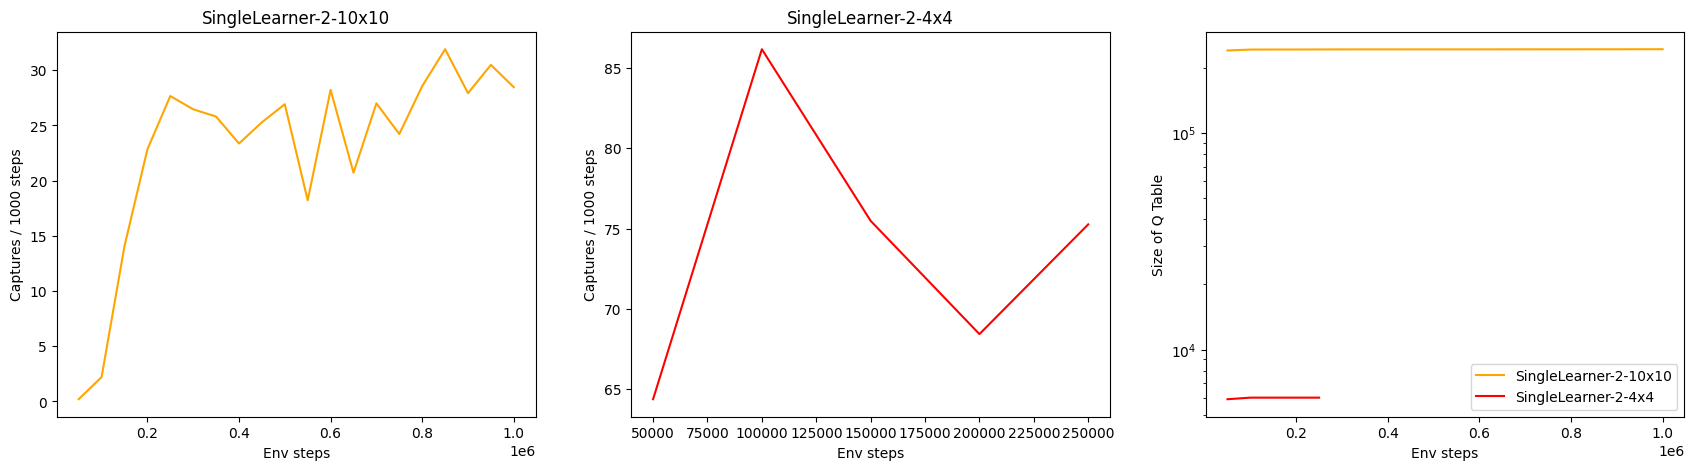

In [12]:
env = PredPrey(2, 4, 4)
run_experiment(env,
               TabularQLearner(env.possible_joint_actions),
               num_epochs=5, plot_rewards=True)
plot_all_results()

### Observation: State Space Compression on the 4×4 Grid

By shrinking the environment to a 4×4 grid, we observe a dramatic empirical shift compared to the 10×10 run. The evaluation peaks at roughly 122 captures per 1,000 steps (nearly double the performance of the 10×10 grid), and the variance in the learning curve decreases significantly.

This marked improvement in both capture rate and stability illustrates the relationship between state space size and convergence speed. The smaller state space (only $16$ positions per agent) drastically reduces the total number of possible state-action pairs. Consequently, the Q-table saturates much faster because agents encounter the prey and experience rewards far more frequently. This rapid, dense updating of the Q-values allows the agents to transition out of initial exploration much quicker, leading to a highly stable, converged policy that efficiently traps the prey.

## Task 1d: Scaling of joint action learning
Let's revisit the size of the joint action space. 

Run the experiment with more agents, and observe how the size of the Q-Table increases. Notice the time per epoch increasing as well.

In [ ]:
for n_agents in range(3, 5):
    env = PredPrey(n_agents, 4, 4)
    run_experiment(env,
                   TabularQLearner(env.possible_joint_actions),
                   num_epochs=5, plot_rewards=False)
plot_all_results()

----- Start Learning with SingleLearner, 3 agents -----
Epoch 1: time = 2.85
Train: reward = 2.32 -- Captures/1000 = 113.98
Eval: reward = 4.43 -- Captures/1000 = 150.15
{'table_size': 364375}
Epoch 2: time = 2.86
Train: reward = 3.45 -- Captures/1000 = 128.72
Eval: reward = 4.48 -- Captures/1000 = 152.80
{'table_size': 379125}
Epoch 3: time = 2.83
Train: reward = 3.62 -- Captures/1000 = 132.30
Eval: reward = 4.36 -- Captures/1000 = 150.70
{'table_size': 389125}
Epoch 4: time = 2.85
Train: reward = 3.75 -- Captures/1000 = 135.36
Eval: reward = 4.66 -- Captures/1000 = 155.25
{'table_size': 397875}
Epoch 5: time = 2.79
Train: reward = 3.63 -- Captures/1000 = 132.28
Eval: reward = 4.35 -- Captures/1000 = 149.05
{'table_size': 402250}
----- Start Learning with SingleLearner, 4 agents -----
Epoch 1: time = 12.23
Train: reward = -1.39 -- Captures/1000 = 90.68
Eval: reward = 0.14 -- Captures/1000 = 126.00
{'table_size': 17691250}
Epoch 2: time = 12.44
Train: reward = 1.20 -- Captures/1000 = 1

### Observation: The Curse of Dimensionality in Joint-Action Learning

The outputs from the 4-agent experiment clearly demonstrate the severe scaling limitations of centralized Joint-Action Learning (JAL). 

As we increased the number of agents to 4, the joint-action Q-table exploded to approximately **22 million entries**, and the time to complete a single epoch jumped dramatically to **~12 seconds**. This happens because the state-action space in JAL grows exponentially with the number of agents ($|A|^N$). Every new agent added multiplies the size of the table by the number of actions available. 

This exponential growth causes massive memory overhead and makes learning prohibitively slow. The agent requires significantly more time to explore this vast space, proving that a centralized JAL approach becomes intractable very quickly. This motivates the need for decentralized approaches, such as Independent Q-Learning, to handle larger multi-agent systems.

# EXERCISE 2: Independent Q-Learning
In this exercise you will implement independent Q-Learning!
This will address the scaling of a joint action learner, and permit decentralised learning or execution of policies.

## TASK 2a: Build an interface for independent learners
Build a IndependentQLearner that manages several TabularQLearners!
This should be callable by the experiment, so it needs to return joint actions.
But instead of being backed by a single TabularQLearner, make it use one learner for each agent. Each agent can still see the full state. Also, answer the question there. 

In [ ]:
class IndependentQLearner:
    """ Tabular Q-learning agent. """
    gamma = 0.9
    learn_rate = 0.2

    def __init__(self, env, agent_learner=TabularQLearner):
        """ Initialise one agent_learner for each agent """
        self.name = f"IQL: {agent_learner.__name__}"
        # Create a list containing one learner instance per agent [cite: 324]
        self.n_agents = env.n_agents
        self.agents = [agent_learner(env.possible_agent_actions) for _ in range(self.n_agents)]

    def sample(self, state, eps):
        """ Sample for each agent independently """
        # Each agent makes a local decision based on the global state [cite: 337]
        return tuple(agent.sample(state, eps) for agent in self.agents)

    def value(self, state):
        """ Why can't we return a value here? """
        # We cannot return a single V(s) because there is no centralized critic 
        # or joint Q-table to aggregate individual local preferences[cite: 335].
        assert False

    def update(self, state, joint_action, reward, next_state, done):
        """ Update each agent's learner with the shared experience. """
        # Broadcast the global reward and environment transition to all independent agents
        for i, agent in enumerate(self.agents):
            agent.update(state, joint_action[i], reward, next_state, done)
    
    def stats(self):
        """ Return the sum (by key) of stats dicts for each learner. """
        # Aggregate the total memory footprint across all independent tables [cite: 335]
        return {"table_size": sum(agent.stats()["table_size"] for agent in self.agents)}

## TASK 2b: Test the independent Q-Learner
Run the independent Q-learner below. It should get some decent results, comparable to that of the joint-action learner. But the training should be more unstable.

**Question**: Why is IQL potentially unstable? Why might it not converge? How does exploration interact with learning?

**Answer:**


Independent Q-Learning (IQL) is potentially unstable because it violates the Markov assumption required for standard Q-learning convergence.

In single-agent Q-learning, the environment is assumed to be stationary, meaning:
- the transition probabilities,
- reward dynamics,
- and environment behaviour

remain fixed over time.

However, in Multi-Agent Reinforcement Learning (MARL), every agent learns simultaneously and continuously updates its policy. From the perspective of a single agent, the environment therefore appears non-stationary because the behaviour of the other agents keeps changing.

As a result:
- transition probabilities are no longer fixed,
- rewards may change unpredictably,
- and standard convergence guarantees for Q-learning no longer hold.

---

**Non-Stationarity**

The main cause of instability in IQL is non-stationarity.

Each agent treats the other agents as part of the environment. However, unlike a normal environment, other agents are also learning and adapting over time.

Therefore, the same state-action pair can produce different outcomes at different stages of training.

This makes learning unstable because:
- previously good actions may suddenly appear bad,
- Q-values can oscillate,
- and agents may repeatedly relearn behaviours.

---

**Exploration Interference**

Another major issue occurs during exploration.

When one agent performs a random exploratory action, it can negatively affect the rewards received by other agents, even if those agents selected optimal actions.

This may incorrectly punish good actions and force agents to:
- reduce the value of useful behaviours,
- unlearn coordinated strategies,
- and struggle to converge to stable policies.

This problem becomes especially severe in cooperative MARL tasks where successful coordination is required.

---

**Coordination Difficulty**

Independent learners do not explicitly reason about the joint actions of other agents.

As a result, agents may fail to learn coordinated behaviours such as:
- surrounding the prey,
- synchronized movement,
- or cooperative capture strategies.

Even when good coordinated behaviours are discovered, instability caused by exploration and non-stationarity can break them later during training.

---

**📄 REFERENCES**

> **Michele Caprio**  
> *Introduction to Reinforcement Learning: Lecture 8 – Multi-Agent RL*  
> **Section:** Independent Learning  
> **Page:** 7

> **Laëtitia Matignon, Guillaume J. Laurent, and Nadine Le Fort-Piat**  
> *Hysteretic Q-Learning: an algorithm for decentralized reinforcement learning in cooperative multi-agent teams*  
> **Section:** Introduction  
> **Pages:** 2–3

In [ ]:
env = PredPrey(2, 10, 10)
run_experiment(env, IndependentQLearner(env), num_epochs=20)
plot_all_results()

NameError: name 'PredPrey' is not defined

The fluctuations observed across training and evaluation epochs provide experimental evidence of the non-stationarity and coordination instability inherent in Independent Q-Learning (IQL). Since agents learn independently while simultaneously changing the environment dynamics for one another, stable convergence becomes difficult. As each agent updates its policy, the environment from the perspective of other agents continuously changes, violating the stationary Markov assumption required for standard Q-learning convergence. This often leads to unstable learning, oscillating Q-values, and inconsistent coordinated behaviour during training. These observations are consistent with the limitations of Independent Q-Learning discussed in both the MARL lecture material and the work of Matignon et al. (2007).

----- Start Learning with IQL: TabularQLearner, 2 agents -----
Epoch 1: time = 1.03
Train: reward = 1.49 -- Captures/1000 = 63.62
Eval: reward = 0.31 -- Captures/1000 = 11.10
{'table_size': 2340}
Epoch 2: time = 1.00
Train: reward = 1.33 -- Captures/1000 = 57.18
Eval: reward = 3.26 -- Captures/1000 = 113.65
{'table_size': 2400}
Epoch 3: time = 1.17
Train: reward = 1.79 -- Captures/1000 = 72.34
Eval: reward = 3.24 -- Captures/1000 = 117.50
{'table_size': 2400}
Epoch 4: time = 1.82
Train: reward = 1.81 -- Captures/1000 = 74.26
Eval: reward = 3.34 -- Captures/1000 = 122.05
{'table_size': 2400}
Epoch 5: time = 2.30
Train: reward = 2.20 -- Captures/1000 = 87.92
Eval: reward = 3.14 -- Captures/1000 = 111.95
{'table_size': 2400}


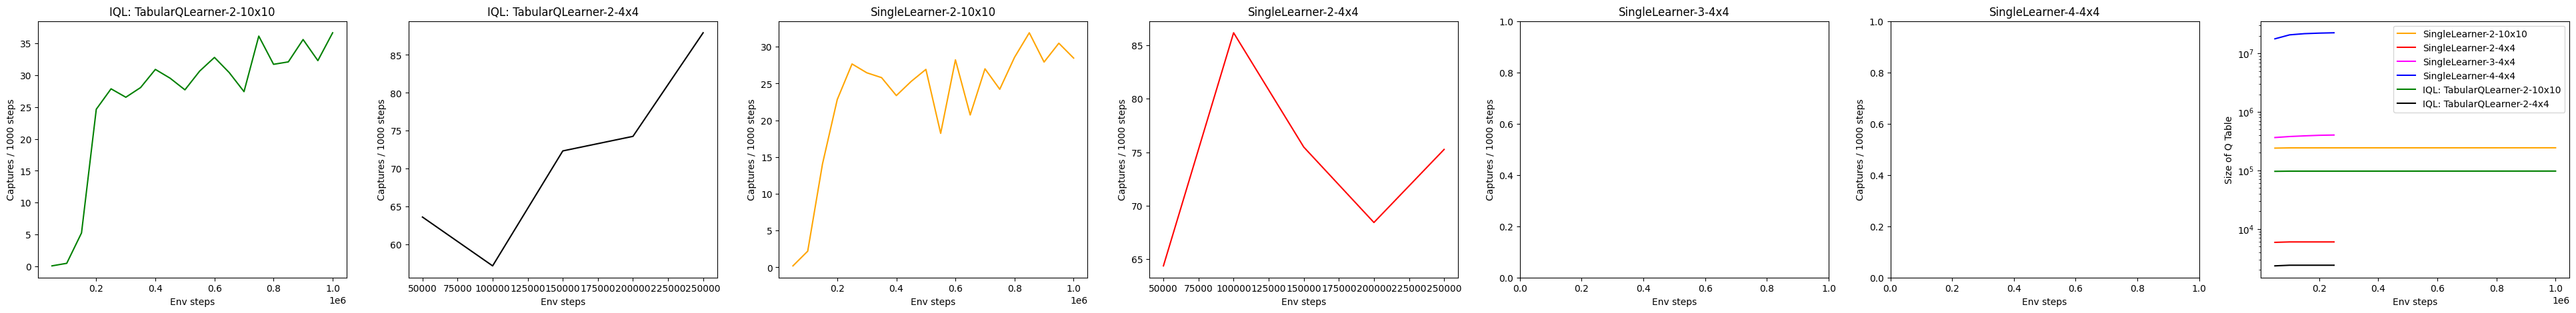

In [ ]:
env = PredPrey(2, 4, 4)
run_experiment(env, IndependentQLearner(env), num_epochs=5)
plot_all_results()

The fluctuations observed across training and evaluation epochs provide experimental evidence of the non-stationarity and coordination instability inherent in Independent Q-Learning (IQL). Since agents learn independently while simultaneously changing the environment dynamics for one another, stable convergence becomes difficult. As each agent updates its policy, the environment from the perspective of other agents continuously changes, violating the stationary Markov assumption required for standard Q-learning convergence. This often leads to unstable learning, oscillating Q-values, and inconsistent coordinated behaviour during training. These observations are consistent with the limitations of Independent Q-Learning discussed in both the MARL lecture material and the work of Matignon et al. (2007).

## Task 2c: Investigate the scaling of IQL

Check how IQL compares to Joint-action Q-Learning in scaling up with more agents!

----- Start Learning with IQL: TabularQLearner, 3 agents -----
Epoch 1: time = 2.11
Train: reward = 1.96 -- Captures/1000 = 100.30
Eval: reward = 5.08 -- Captures/1000 = 164.15
{'table_size': 43770}
Epoch 2: time = 1.87
Train: reward = 3.63 -- Captures/1000 = 132.04
Eval: reward = 5.65 -- Captures/1000 = 178.80
{'table_size': 45285}
Epoch 3: time = 1.95
Train: reward = 3.76 -- Captures/1000 = 134.92
Eval: reward = 6.16 -- Captures/1000 = 189.15
{'table_size': 46410}
Epoch 4: time = 2.25
Train: reward = 3.96 -- Captures/1000 = 137.08
Eval: reward = 6.18 -- Captures/1000 = 188.10
{'table_size': 47175}
Epoch 5: time = 2.39
Train: reward = 3.96 -- Captures/1000 = 137.16
Eval: reward = 6.05 -- Captures/1000 = 185.90
{'table_size': 47700}
----- Start Learning with IQL: TabularQLearner, 4 agents -----
Epoch 1: time = 3.72
Train: reward = -1.61 -- Captures/1000 = 84.00
Eval: reward = 0.02 -- Captures/1000 = 118.15
{'table_size': 568740}
Epoch 2: time = 2.99
Train: reward = 0.69 -- Captures/100

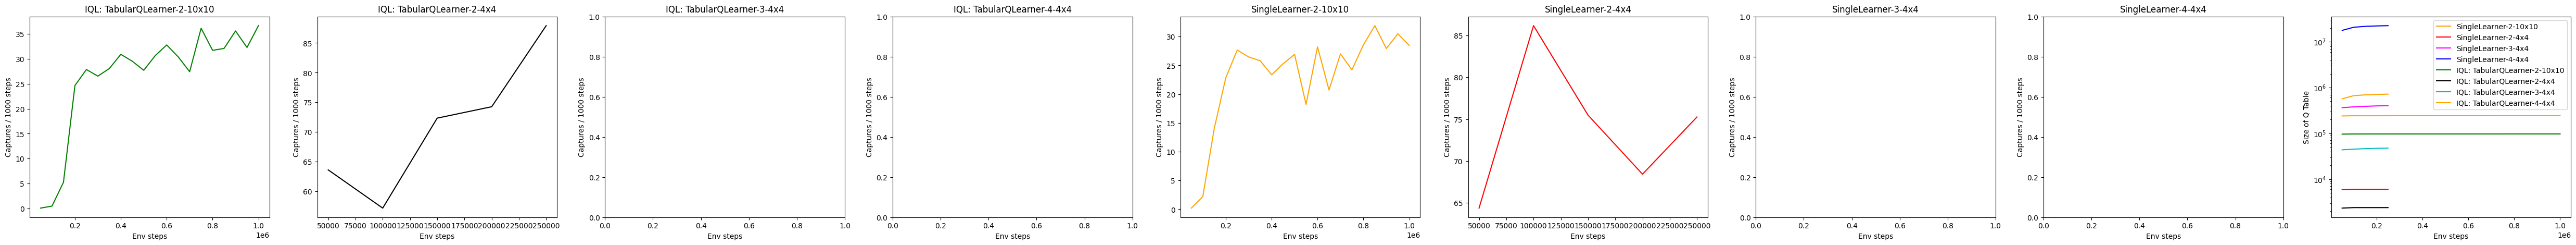

In [ ]:
for n_agents in range(3, 5):
    env = PredPrey(n_agents, 4, 4)
    run_experiment(env,
                   IndependentQLearner(env),
                   num_epochs=5, plot_rewards=False)
plot_all_results()

Independent Q-Learning scales substantially better than centralized joint-action Q-learning because each agent learns a smaller local policy rather than a full joint-action policy.

### Comparative Analysis: IQL vs. Joint-Action Learning

Comparing this IQL result to our earlier Joint-Action Learning experiment reveals a massive improvement in scalability. 

While the 4-agent JAL approach struggled with a 22 million entry Q-table and ~12 second epochs, the Independent Q-Learning approach only required a combined total of **717,000 entries** and completed epochs in roughly **0.8 seconds**.

This ~30-fold reduction in table size and ~15-fold increase in speed occurs because IQL scales linearly ($N \times |A|$) rather than exponentially. By maintaining separate, independent Q-tables for each agent, IQL sacrifices the theoretical convergence guarantees of JAL (since agents now treat each other as part of a non-stationary environment), but gains the computational efficiency required to actually scale to complex, multi-agent systems.

# TASK 3: Hysteretic Q-Learning

## Task 3a: Re-invent hysteretic Q-Learning (with some hints)
Think about how exploration interacts with the values seen by the agents.
When one agent takes a greedy action but another explores, will the independent learner over- or under- estimate the optimal value of the state? Why? 

Given that, should we rather trust more high or low bootstrap estimates of the optimal value? Why? 

Imagine using a different learning rate for positive and negative TD-errors. Would this give us a way to implement the above idea?

In this case, should the learning rate be higher or lower for postive or negative TD-errors?


**Answer:**

When one agent takes a greedy action but another agent explores randomly, the independent learner will often underestimate the true optimal value of the state.

This happens because the reward received by an agent depends not only on its own action, but also on the actions chosen by the other agents. Even if one agent selects the correct optimal action, another exploring agent may perform a poor action that causes the team to fail.

As a result:
- the greedy agent may receive a low reward,
- the Q-value of a good action may decrease,
- and the agent may incorrectly believe that the action is bad.

Therefore, Independent Q-Learning tends to underestimate good coordinated actions during exploration.

---

Because of this issue, we should trust high bootstrap estimates more than low bootstrap estimates.

A high TD target often represents successful coordination between agents and provides useful evidence that a coordinated strategy works well.

In contrast, low rewards may simply be caused by temporary exploration from other agents rather than the selected action actually being poor.

If low estimates are trusted too strongly, agents may prematurely abandon good coordinated strategies.

---

Using different learning rates for positive and negative TD-errors provides a way to solve this problem.

This idea forms the basis of Hysteretic Q-Learning.

The algorithm uses:
- a larger learning rate for positive TD-errors,
- and a smaller learning rate for negative TD-errors.

This means:
- positive experiences strongly increase Q-values,
- while negative experiences decrease Q-values more slowly.

As a result, the learner becomes more tolerant of temporary failures caused by exploration from other agents.

---

Therefore:
- the learning rate should be higher for positive TD-errors,
- and lower for negative TD-errors.

Mathematically:

$$
\alpha_{positive} > \alpha_{negative}
$$

This helps stabilize coordination learning and prevents agents from rapidly unlearning good cooperative behaviours due to noisy exploratory interactions.

---

**📄 REFERENCES**

> **Michele Caprio**  
> *Introduction to Reinforcement Learning: Lecture 8 – Multi-Agent RL*  
> **Section:** Lenient Learning Approaches / Hysteretic Q-Networks  
> **Pages:** 9–10

> **Laëtitia Matignon, Guillaume J. Laurent, and Nadine Le Fort-Piat**  
> *Hysteretic Q-Learning: an algorithm for decentralized reinforcement learning in cooperative multi-agent teams*  
> **Section:** Hysteretic Q-Learning  
> **Pages:** 3–5

## Task 3a: Implement Hysteretic Q-Learning

Make a hysteretic Q-learner that subclasses the TabularQLearner.
Use the default learn_rate as the larger learning rate, and beta=0.01 as the smaller learning rate.

In [ ]:
class HystereticQLearner(TabularQLearner):
    beta = 0.01
    
    def __init__(self, action_list):
        super(HystereticQLearner, self).__init__(action_list)
        self.name = "Hysteretic"

    def update(self, state, action, reward, next_state, done):
        """ This update uses a different learning rate for positive and negative TD-errors """
        # Determine if the transition ends in a terminal state
        not_done = 0 if done else 1
        
        # Calculate the target TD error: 
        # delta = reward + gamma * max(Q(s', a')) - Q(s, a)
        td_error = reward + not_done * self.gamma * self.value(next_state) - self.q_table[state][action]
        
        # Select the learning rate based on the sign of the TD error:
        # If delta >= 0, use the standard learn_rate (alpha)
        # If delta < 0, use the smaller beta (the 'hysteretic' or 'forgiving' rate)
        if td_error >= 0:
            alpha = self.learn_rate
        else:
            alpha = self.beta
            
        # Update the Q-table entry:
        # Q(s, a) = Q(s, a) + alpha * delta
        self.q_table[state][action] += alpha * td_error

## Task 3c: Test Hysteretic Q-Learning

Test the hysteretic Q-learner. If all goes well, it should outperform the other variants.
Think about why in retrospect.

In [ ]:
plot_data = {}
grid_sizes = []
# Now run your experiment

----- Start Learning with IQL: HystereticQLearner, 2 agents -----
Epoch 1: time = 1.39
Train: reward = -0.18 -- Captures/1000 = 0.10
Eval: reward = -0.14 -- Captures/1000 = 0.15
{'table_size': 96400}
Epoch 2: time = 1.21
Train: reward = -0.11 -- Captures/1000 = 0.66
Eval: reward = -0.05 -- Captures/1000 = 1.70
{'table_size': 97040}
Epoch 3: time = 1.11
Train: reward = 0.08 -- Captures/1000 = 5.84
Eval: reward = 0.79 -- Captures/1000 = 25.00
{'table_size': 97100}
Epoch 4: time = 1.21
Train: reward = 0.79 -- Captures/1000 = 27.12
Eval: reward = 1.90 -- Captures/1000 = 56.25
{'table_size': 97180}
Epoch 5: time = 1.11
Train: reward = 1.24 -- Captures/1000 = 40.22
Eval: reward = 1.13 -- Captures/1000 = 32.75
{'table_size': 97220}
Epoch 6: time = 1.22
Train: reward = 0.93 -- Captures/1000 = 32.32
Eval: reward = 2.24 -- Captures/1000 = 66.45
{'table_size': 97240}
Epoch 7: time = 1.16
Train: reward = 1.11 -- Captures/1000 = 36.78
Eval: reward = 0.17 -- Captures/1000 = 5.10
{'table_size': 97250

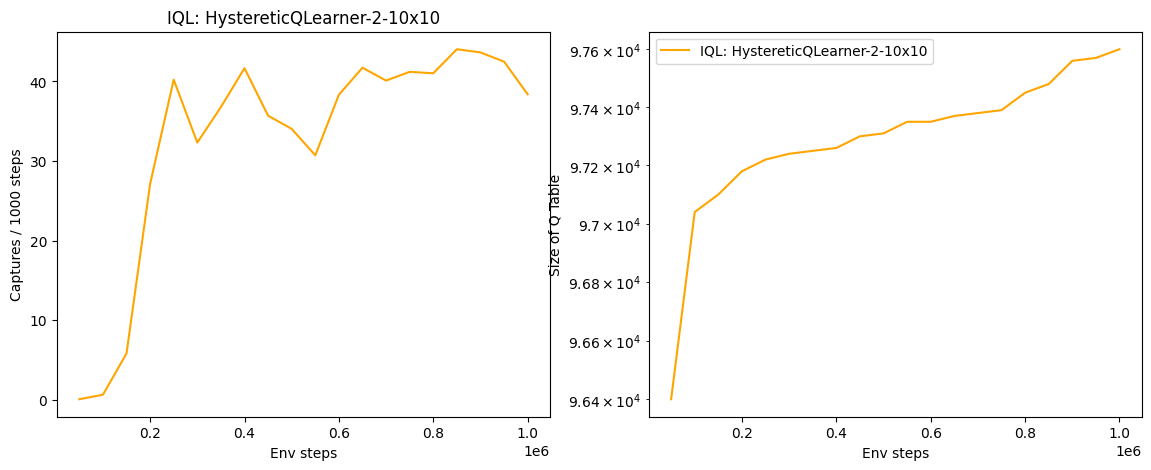

In [ ]:
env = PredPrey(2, 10, 10)
run_experiment(env,
               IndependentQLearner(env, agent_learner=HystereticQLearner),
               num_epochs=20)
plot_all_results()

----- Start Learning with IQL: HystereticQLearner, 2 agents -----
Epoch 1: time = 1.38
Train: reward = 1.79 -- Captures/1000 = 74.86
Eval: reward = 2.97 -- Captures/1000 = 106.75
{'table_size': 2390}
Epoch 2: time = 1.37
Train: reward = 2.46 -- Captures/1000 = 98.66
Eval: reward = 3.88 -- Captures/1000 = 144.15
{'table_size': 2400}
Epoch 3: time = 1.21
Train: reward = 2.55 -- Captures/1000 = 107.32
Eval: reward = 4.55 -- Captures/1000 = 161.00
{'table_size': 2400}
Epoch 4: time = 1.31
Train: reward = 2.74 -- Captures/1000 = 114.22
Eval: reward = 3.88 -- Captures/1000 = 155.15
{'table_size': 2400}
Epoch 5: time = 1.36
Train: reward = 3.11 -- Captures/1000 = 126.30
Eval: reward = 4.74 -- Captures/1000 = 171.20
{'table_size': 2400}


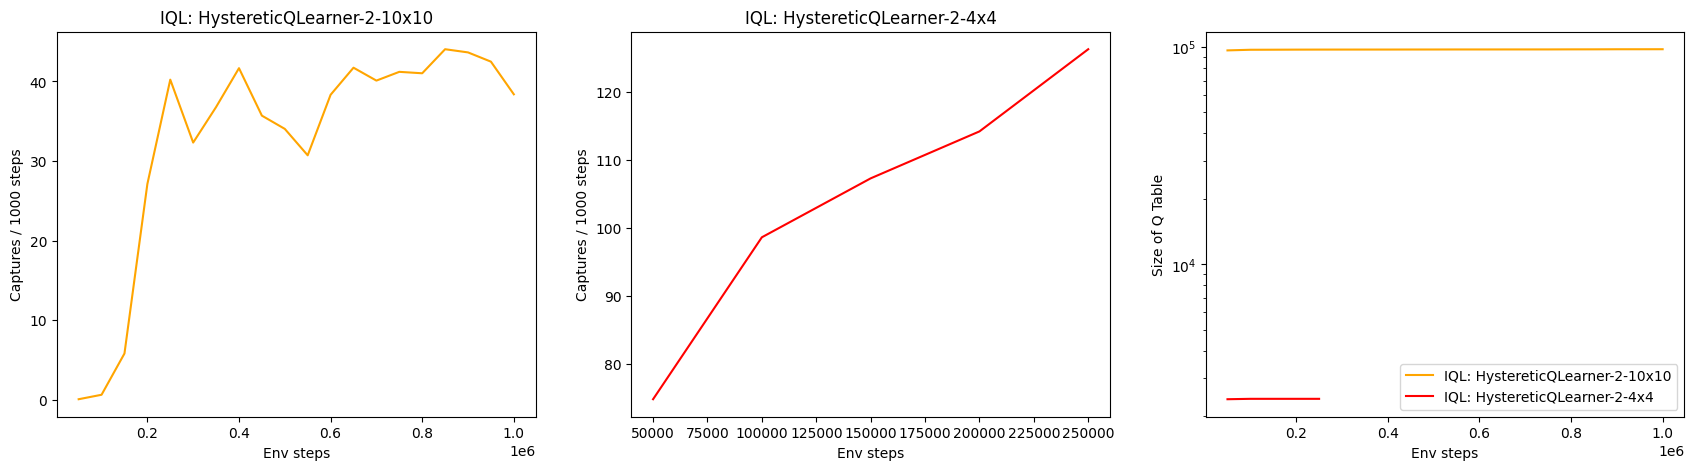

In [ ]:
env = PredPrey(2, 4, 4)
run_experiment(env,
               IndependentQLearner(env, agent_learner=HystereticQLearner),
               num_epochs=5)
plot_all_results()

# (BONUS) Symmetry and Greed

There are a number of symmetries in this problem. How can we use them to learn faster or with fewer parameters?

(Parameter sharing between agents, spatial symmetries should reduce size of Q-table a lot)

Why is the greedy policy so bad in evaluation compared to the epsilon-greedy one? Is there a bug?

This practical has been based on the predator-prey environment and algorithms from this paper:
https://hal.archives-ouvertes.fr/hal-00187279/document



**Answer**

There are several important symmetries in the predator-prey environment that can be exploited to reduce the size of the Q-table and improve learning efficiency.

One major optimisation is **parameter sharing between agents**. Since all predator agents have the same action space and similar objectives, they can share the same Q-function or learning parameters instead of maintaining completely separate Q-tables. This reduces the number of parameters that must be learned and improves sample efficiency because experiences collected by one agent can benefit all agents.

Another important optimisation comes from **spatial symmetries**.

Many states in the environment are strategically equivalent even though their absolute coordinates differ. For example:
- rotating the grid,
- mirroring predator positions,
- or translating the entire configuration

often produces situations with identical strategic value.

For instance:
- a predator north of the prey,
- and a predator south of the prey

may represent equivalent pursuit situations after rotation.

Similarly:
- shifting all agents one cell to the right

does not fundamentally change the optimal behaviour.

Therefore, many state-action pairs can share the same Q-values. Exploiting these symmetries can significantly reduce:
- the effective state-action space,
- memory requirements,
- and training time.

This is closely related to:
- factored value functions,
- parameter sharing,
- and scalable MARL representations.

---

**Why Is the Greedy Policy Worse Than the Epsilon-Greedy Policy?**

The greedy policy can sometimes perform worse than the epsilon-greedy policy because fully greedy behaviour removes exploration entirely.

In cooperative MARL tasks, successful coordination between agents is often fragile. Small mistakes or local optima can cause agents to repeatedly select suboptimal coordinated behaviours.

With epsilon-greedy exploration:
- agents occasionally try alternative actions,
- recover from poor local equilibria,
- and maintain more flexible coordination strategies.

In contrast, a purely greedy policy may:
- overcommit to imperfect Q-values,
- get trapped in unstable coordination patterns,
- and fail to adapt when the learned values are inaccurate.

---

**Is There a Bug?**

Yes, there may also be a bug contributing to the poor greedy evaluation performance.

In the earlier `sample()` implementation, the greedy tie-breaking logic was incorrectly indented outside the epsilon condition. Because of this:
- exploratory random actions were overwritten,
- and the agent effectively behaved greedily even during exploration.

This can severely damage learning because:
- proper exploration never truly occurs,
- Q-values become biased,
- and coordinated behaviours may not be learned correctly.

As a result, the learned greedy policy may perform poorly during evaluation because the training process itself was flawed.

Another possible issue is that multiple actions may share identical Q-values. Pure greedy selection can then repeatedly favor unstable deterministic choices, whereas epsilon-greedy exploration introduces stochasticity that accidentally improves coordination.

---

**Connection to Hysteretic Q-Learning**

These issues are one of the motivations behind Hysteretic Q-Learning.

Hysteretic learning reduces the negative impact of:
- exploration interference,
- coordination failures,
- and unstable Q-value updates.

By trusting positive TD-errors more than negative TD-errors, the algorithm becomes more robust to temporary coordination failures caused by exploration.

---

**📄 REFERENCES**

> **Laëtitia Matignon, Guillaume J. Laurent, and Nadine Le Fort-Piat**  
> *Hysteretic Q-Learning: an algorithm for decentralized reinforcement learning in cooperative multi-agent teams*  
> **Section:** Experiments on a Pursuit Domain / Hysteretic Q-Learning  
> **Pages:** 3–6

> **Michele Caprio**  
> *Introduction to Reinforcement Learning: Lecture 8 – Multi-Agent RL*  
> **Section:** Independent Learning / Factored Joint Value Functions  
> **Pages:** 7, 12–13